# 04 · Robustesse sur toute l'année 2024, et ce que les tests permettent de conclure

**Bloc 5 · W37 — mini-projet éCO2mix, notebook 4 sur 4.**

Le notebook 03 s'est arrêté sur un constat : 4 origines ne suffisent pas à classer des méthodes dont les écarts
sont de quelques pourcents. Le protocole prévoyait, dès le départ, une **étude de robustesse** : une origine
tous les 3 jours sur l'année 2024, soit **119 origines**, tous les jours de la semaine et toutes les saisons.

| § | Question | Outil |
|---|---|---|
| 1 | Que donne le tableau sur 119 origines ? | tableau + figure clé |
| 2 | Les écarts entre méthodes sont-ils réels ? | 🔬 tests appariés (t, Wilcoxon, HAC) + Holm |
| 3 | Les 4 origines de novembre étaient-elles représentatives ? | distribution des écarts |
| 4 | Le résultat tient-il région par région ? | 🔬 13 tests de Wilcoxon + Holm |
| 5 | Pourquoi MinT shrink perd-il ? | 🔬 les résidus in-sample face aux vraies erreurs |
| 6 | Et si W était bien estimée ? | 🧪 expérience contrôlée : W estimée sur les erreurs passées |
| 7 | Les prévisions de base sont-elles biaisées, hors échantillon ? | 🔬 H1, enfin testée correctement |
| 8 | Conclusion | le chiffre clé, et la réponse à l'objectif métier |

Le backtest tourne en ligne de commande (`uv run w37 eco2mix backtest --which robustness`, une quarantaine de
minutes) ; ce notebook relit ses résultats.

> **Comment lire ce notebook.** Les encadrés suivent un code fixe :
> 💡 **Intuition**, l'idée sans les équations · 🧪 **Exemple**, une expérience chiffrée ·
> ⚠️ **Point d'attention**, le piège à éviter · 📌 **À retenir**, le mémo à garder ·
> 🔬 **Test d'hypothèse**, une hypothèse formulée, testée, puis acceptée ou rejetée.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, Markdown

from w37_reconciliation import viz
from w37_reconciliation.eco2mix import run, prepare, source, metrics, inference, figures

viz.setup()
pd.set_option("display.precision", 3)
cfg, paths = run.load_config()
if not (paths.interim / "hourly_regions.parquet").exists():
    raise FileNotFoundError("Données absentes : lancer d'abord `uv run w37 eco2mix download` puis `prepare`.")
FIG = Path("../figures"); FIG.mkdir(exist_ok=True)
def export(fig, name):
    """Exporte la figure en SVG pour le README."""
    fig.savefig(FIG / f"{name}.svg", bbox_inches="tight")
from scipy import stats
from w37_reconciliation.data import to_wide
from w37_reconciliation.eco2mix.backtest import BacktestSpec, reconcile_with_past_errors

hier = run.load_hierarchy(cfg, paths)
order = hier.order
res = run.load_results(paths, "robustness")
fc, scales, diag = res["forecasts"], res["scales"], res["diagnostics"]
RECONCILED = ["BU", "OLS", "WLS struct", "WLS var", "MinT shrink"]
ALPHA = cfg["inference"]["alpha"]
origins = pd.to_datetime(sorted(fc["origin"].unique()))
print(f"{len(origins)} origines, du {origins.min():%d %b} au {origins.max():%d %b %Y}, tous les 3 jours")
print("répartition par jour de la semaine :", pd.Series(origins.day_name()).value_counts().to_dict())

119 origines, du 09 Jan au 28 Dec 2024, tous les 3 jours
répartition par jour de la semaine : {'Tuesday': 17, 'Friday': 17, 'Monday': 17, 'Thursday': 17, 'Sunday': 17, 'Wednesday': 17, 'Saturday': 17}


## 1. Le tableau sur 119 origines

Assertion de cohérence sur 119 origines : OK (max 0.0e+00 MW)


,France mean,France std,Régions mean,Régions std
method,,,,
SN,0.947,0.996,0.939,0.812
base,0.368,0.387,0.427,0.291
BU,0.352,0.356,0.427,0.291
OLS,0.366,0.385,0.439,0.316
WLS struct,0.358,0.371,0.432,0.304
WLS var,0.356,0.368,0.430,0.299
MinT shrink,0.370,0.388,0.439,0.315


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


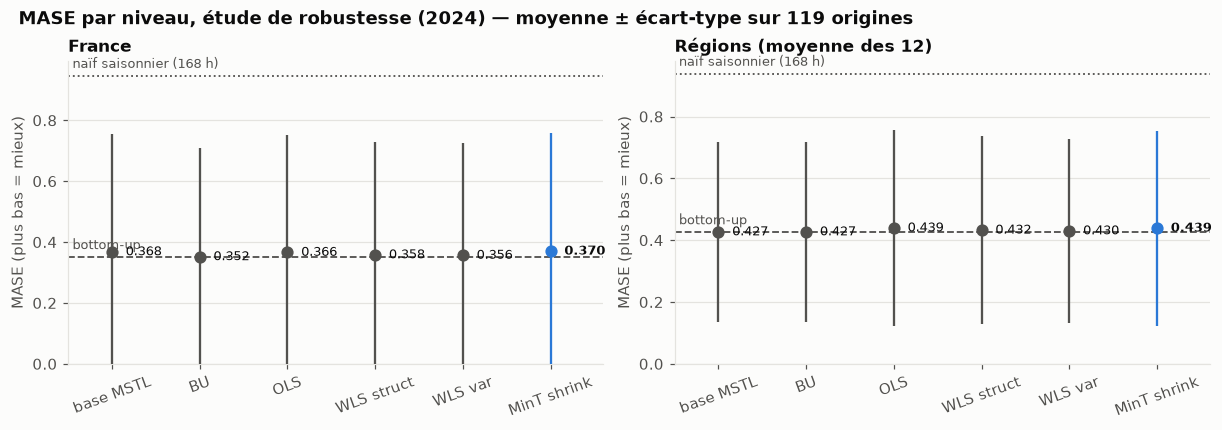

In [2]:
tol = float(cfg["inference"]["coherence_tol_abs"])
incoh = metrics.assert_coherent(fc, hier, RECONCILED, tol)
print(f"Assertion de cohérence sur 119 origines : OK (max {incoh.to_numpy().max():.1e} MW)")
mase = metrics.mase_long(fc, scales, hier)
by_level = metrics.mase_by_level(mase)
display(metrics.summary_table(by_level, ["SN", "base", *RECONCILED]).style.format("{:.3f}")
        .highlight_min(subset=["France mean", "Régions mean"], color="#cde2fb"))
fig = figures.key_figure(by_level, "MASE par niveau, étude de robustesse (2024)", show_origins=False)
export(fig, "figure_cle_robustesse"); plt.show()

**Lecture.** Trois constats, tous différents du protocole principal :

1. MSTL bat toujours largement le naïf saisonnier : la baseline n°1 tient sur l'année.
2. **Le bottom-up est la meilleure réconciliation**, aux deux niveaux. Au niveau France, il fait même mieux que
   la prévision MSTL directe du total : additionner 12 prévisions régionales bat la prévision du total.
3. **MinT shrink et OLS sont les moins bons.** Les méthodes à W diagonale (WLS) sont entre les deux.

Mais l'écart-type entre origines reste du même ordre que la moyenne : la question de la section suivante est
de savoir si ces écarts sont réels.

## 2. 🔬 Les écarts entre méthodes sont-ils réels ?

**Unité d'analyse.** On compare les méthodes **origine par origine** : à chaque origine, les deux méthodes
partent des mêmes prévisions de base et sont jugées sur les mêmes 24 heures. On teste la différence de MASE,
une valeur par origine, avec trois tests complémentaires :

| Test | H0 | Ce qu'il suppose |
|---|---|---|
| t apparié | la différence moyenne est nulle | différences à peu près normales et indépendantes |
| Wilcoxon signé | la différence médiane est nulle | rien sur la forme, mais l'indépendance |
| t HAC | la différence moyenne est nulle | robuste à l'autocorrélation entre origines voisines (3 jours) |

On fait 8 comparaisons (4 méthodes × 2 niveaux, toujours contre BU) : les p-valeurs sont corrigées par **Holm**.

In [3]:
rows = {}
for level in ["Régions", "France"]:
    w = by_level[by_level["level"] == level].pivot(index="origin", columns="method", values="mase")
    for m in ["OLS", "WLS struct", "WLS var", "MinT shrink"]:
        d = (w[m] - w["BU"]).to_numpy()
        rel = w[m] / w["BU"] - 1
        rows[(level, m)] = {"variation moyenne": rel.mean(), "variation médiane": rel.median(),
                            "origines gagnées": (rel < 0).mean(),
                            "p t": stats.ttest_1samp(d, 0).pvalue, "p Wilcoxon": stats.wilcoxon(d).pvalue,
                            "p HAC": inference.hac_mean_test(d)["p"]}
tests = pd.DataFrame(rows).T
for col in ["p t", "p Wilcoxon", "p HAC"]:
    tests[col + " (Holm)"] = inference.holm(tests[col], ALPHA)["p_holm"].to_numpy()
display(tests.drop(columns=["p t", "p Wilcoxon", "p HAC"]).style
        .format({"variation moyenne": "{:+.2%}", "variation médiane": "{:+.2%}", "origines gagnées": "{:.0%}",
                 "p t (Holm)": "{:.3f}", "p Wilcoxon (Holm)": "{:.3f}", "p HAC (Holm)": "{:.3f}"})
        .set_caption("Chaque méthode comparée au bottom-up (variation négative = meilleure que BU)"))

**Conclusion des tests.**

- **Aucune méthode ne bat le bottom-up** : toutes les variations moyennes et médianes sont positives, aux deux
  niveaux, et chaque méthode gagne à moins d'une origine sur deux.
- **MinT shrink et OLS sont les plus éloignés du bottom-up.** Après correction de Holm, leur écart reste
  significatif au **test t** (p ≈ 0,05), mais passe juste au-dessus de 5 % pour Wilcoxon et HAC. La preuve est
  donc **modérée** : un effet de signe constant, une significativité limite.
- Les méthodes **WLS** sont proches du bottom-up, et leurs écarts ne sont pas significatifs.

⚠️ **Point d'attention — corriger pour les tests multiples change la conclusion.** Sans correction, les trois
tests rejetteraient H0 pour MinT shrink. Avec 8 comparaisons, il faut s'attendre à des faux positifs, et Holm
remonte les p-valeurs en conséquence. Rapporter seulement les p-valeurs brutes aurait surestimé la preuve.

⚠️ **Point d'attention — moyenne et médiane ne disent pas la même chose.** La variation moyenne de MinT shrink est
de quelques pourcents ; la médiane est bien plus petite. La perte est faite de nombreuses petites défaites et de
quelques grosses. C'est pourquoi on
regarde aussi le test de Wilcoxon, qui porte sur les rangs et résiste aux origines extrêmes.

## 3. Les 4 origines de novembre étaient-elles représentatives ?

Le protocole principal donnait MinT shrink **gagnant** de 2 % au niveau régional. On place ces 4 valeurs dans la
distribution des 119 origines de l'année.

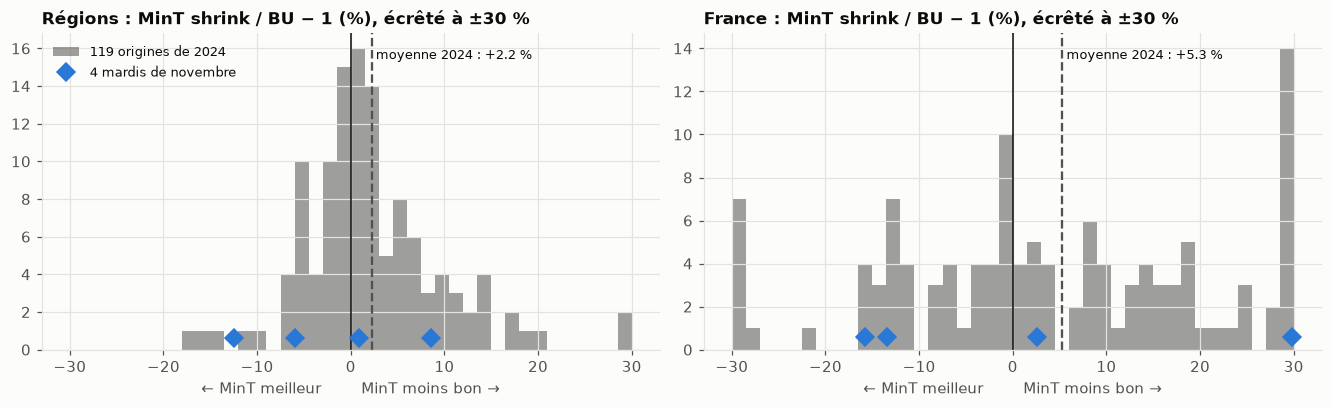

In [4]:
main = run.load_results(paths, "main")
bl_main = metrics.mase_by_level(metrics.mase_long(main["forecasts"], main["scales"], hier))
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), layout="constrained")
for ax, level in zip(axes, ["Régions", "France"]):
    r = metrics.relative_change(by_level, "MinT shrink", "BU", level) * 100
    rm = metrics.relative_change(bl_main, "MinT shrink", "BU", level) * 100
    bins = np.linspace(-30, 30, 41)
    ax.hist(r.clip(-30, 30), bins=bins, color=viz.TEXT_2, alpha=0.55, label="119 origines de 2024")
    ax.axvline(0, color=viz.TEXT, lw=1)
    ax.axvline(r.mean(), color=viz.TEXT_2, lw=1.5, ls="--")
    ax.text(r.mean(), ax.get_ylim()[1] * 0.95, f" moyenne 2024 : {r.mean():+.1f} %", fontsize=8.5, va="top")
    ax.plot(rm.clip(-30, 30), np.full(len(rm), 0.6), "D", color=viz.BLUE, ms=8, label="4 mardis de novembre")
    ax.set_title(f"{level} : MinT shrink / BU − 1 (%), écrêté à ±30 %")
    ax.set_xlabel("← MinT meilleur        MinT moins bon →")
axes[0].legend(fontsize=8.5, loc="upper left")
export(fig, "distribution_ecarts"); plt.show()

**Lecture.** La distribution des écarts est **centrée un peu à droite de zéro** (MinT en moyenne moins bon) et
très **étalée** : selon l'origine, MinT gagne ou perd de 10 à 20 %. Avec 4 tirages dans une telle distribution, on
peut obtenir à peu près n'importe quel signe. Les 4 mardis de novembre sont tombés dans la partie gauche : ce
n'est pas une erreur de protocole, c'est la variance d'échantillonnage.

📌 **À retenir.** Un classement de méthodes n'a de sens qu'accompagné de la dispersion **de la différence** et
d'un nombre d'origines suffisant. C'était l'exigence « écart-type entre origines » de la Definition of Done ; le
§ 2 montre qu'il faut aller jusqu'au test.

## 4. 🔬 Le résultat tient-il région par région ?

Le niveau « Régions » est une moyenne de 12 séries. On refait la comparaison MinT shrink contre BU **pour
chaque série** : 13 tests de Wilcoxon, corrigés par Holm.

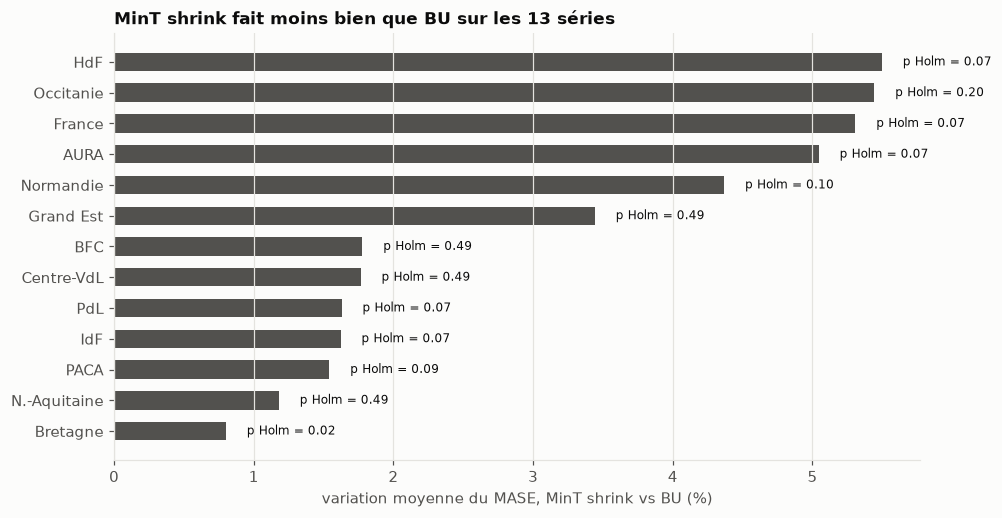

séries où MinT shrink est moins bon en moyenne : 13 / 13 ; différences significatives après Holm : 1


In [5]:
per = mase.pivot_table(index=["origin", "unique_id"], columns="method", values="mase").reset_index()
rows = {}
for uid, g in per.groupby("unique_id"):
    d = g["MinT shrink"] - g["BU"]
    rows[prepare.short_name(uid)] = {"variation moyenne": (g["MinT shrink"] / g["BU"] - 1).mean(),
                                     "MinT gagne": (d < 0).mean(), "p": stats.wilcoxon(d).pvalue}
reg = pd.DataFrame(rows).T
reg = reg.join(inference.holm(reg["p"], ALPHA)[["p_holm", "rejet"]]).sort_values("variation moyenne")
fig, ax = plt.subplots(figsize=(9, 4.6), layout="constrained")
y = np.arange(len(reg))
ax.axvline(0, color=viz.TEXT, lw=1)
ax.barh(y, reg["variation moyenne"] * 100, color=viz.TEXT_2, height=0.6)
for i, (name, r) in enumerate(reg.iterrows()):
    ax.text(r["variation moyenne"] * 100 + 0.15, i, f"p Holm = {r['p_holm']:.2f}", va="center", fontsize=8)
ax.set_yticks(y, reg.index); ax.grid(axis="y", visible=False)
ax.set_xlabel("variation moyenne du MASE, MinT shrink vs BU (%)")
ax.set_title("MinT shrink fait moins bien que BU sur les 13 séries")
export(fig, "par_region"); plt.show()
print(f"séries où MinT shrink est moins bon en moyenne : {(reg['variation moyenne'] > 0).sum()} / {len(reg)} ; "
      f"différences significatives après Holm : {reg['rejet'].sum()}")

**Conclusion.** MinT shrink fait moins bien que le bottom-up **sur les 13 séries sans exception**. Mais prise
une par une, une seule différence résiste à la correction de Holm.

💡 **Ce n'est pas une contradiction.** Treize effets petits et de même signe sont très improbables par hasard :
sous H0 « aucune différence », la probabilité d'avoir 13 signes positifs sur 13 est 1/2¹³ ≈ 0,0001 (test du signe,
en supposant les séries indépendantes ; elles sont corrélées, donc la vraie probabilité est plus grande, mais
reste faible). Chaque test individuel, lui, a peu de puissance, et la correction pour 13 tests la réduit encore.
C'est pour cela qu'on teste **d'abord au niveau** (§ 2), puis qu'on regarde le détail.

## 5. 🔬 Pourquoi MinT shrink perd-il ? L'hypothèse cachée, testée

Le notebook 02 a formulé une hypothèse : W est estimée sur les **résidus in-sample** de MSTL, qui sont des
restes de lissage, peu corrélés entre régions. Les **vraies erreurs** de prévision à 24 h, elles, subissent les
chocs nationaux. Si c'est vrai, MinT pondère avec une W fausse.

- **H0** : la corrélation moyenne entre régions des erreurs hors échantillon est égale à celle des résidus
  in-sample.
- **Test** : on estime la corrélation des erreurs hors échantillon sur les 119 origines, avec un intervalle de
  confiance par **bootstrap sur les origines** (on rééchantillonne des journées entières, pour garder la
  dépendance entre heures). On la compare aux résidus in-sample des 4 origines du protocole principal.

In [6]:
err = (fc.assign(e=fc["y"] - fc["base"]).pivot_table(index=["origin", "ds"], columns="unique_id", values="e")[order])

def mean_corr_regions(E):
    R = np.corrcoef(E[:, 1:].T)
    return R[~np.eye(R.shape[0], dtype=bool)].mean()

rng = np.random.default_rng(37)
boot = [mean_corr_regions(err.loc[rng.choice(origins, len(origins))].to_numpy()) for _ in range(1000)]
oos = mean_corr_regions(err.to_numpy()); lo, hi = np.percentile(boot, [2.5, 97.5])

from statsforecast import StatsForecast
from statsforecast.models import MSTL
from w37_reconciliation.eco2mix.backtest import split_at
spec = BacktestSpec.from_config(cfg)
ins, ins_std = [], []
for o in cfg["backtest"]["main_origins"]:
    tr, _ = split_at(hier.Y_df, pd.Timestamp(o), spec)
    sf = StatsForecast(models=[MSTL(season_length=[24, 168])], freq="h", n_jobs=-1)
    sf.forecast(df=tr, h=1, fitted=True)
    fv = sf.forecast_fitted_values()
    E = (to_wide(fv, order, "y") - to_wide(fv, order, "MSTL")).dropna()
    ins.append(mean_corr_regions(E.to_numpy())); ins_std.append(E.std())
print(f"corrélation moyenne entre régions, erreurs hors échantillon : {oos:.2f}  (IC 95 % bootstrap [{lo:.2f}, {hi:.2f}])")
print("corrélation moyenne entre régions, résidus in-sample (4 origines) : " + ", ".join(f"{v:.2f}" for v in ins))

corrélation moyenne entre régions, erreurs hors échantillon : 0.56  (IC 95 % bootstrap [0.45, 0.65])
corrélation moyenne entre régions, résidus in-sample (4 origines) : 0.11, 0.12, 0.13, 0.13


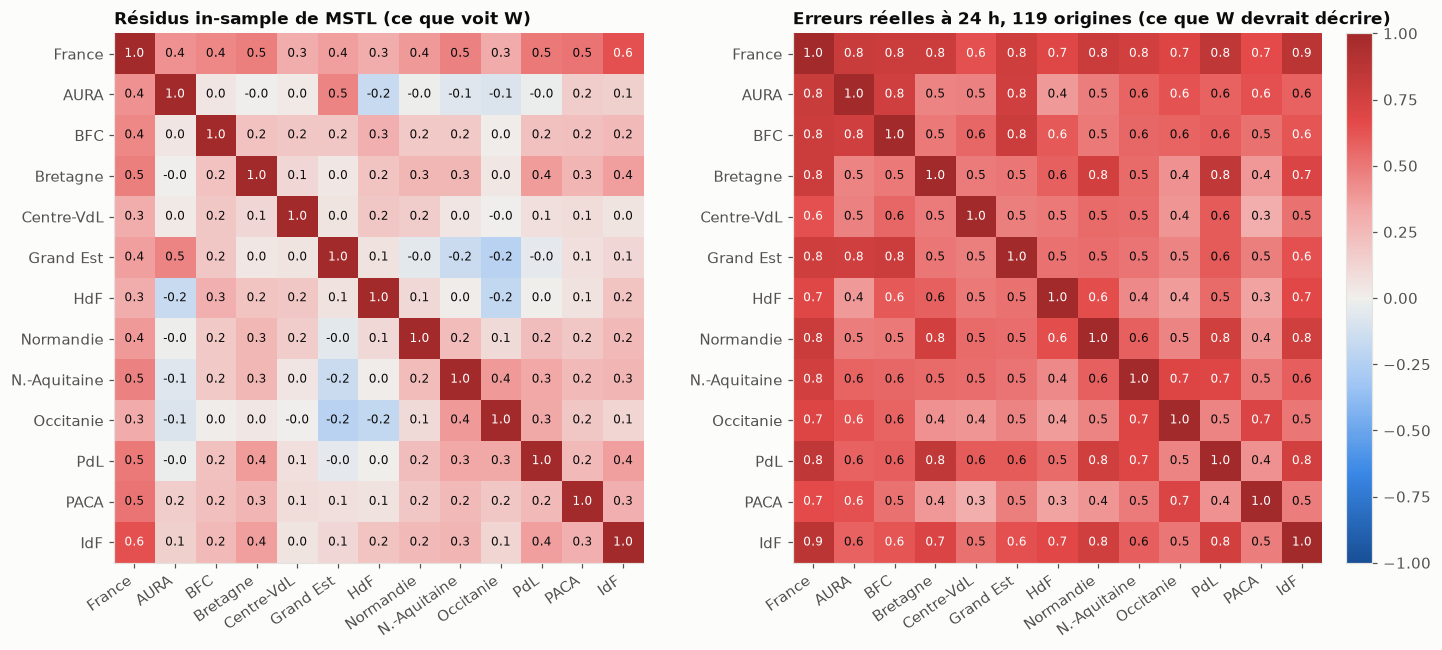

écart-type des erreurs réelles / écart-type des résidus in-sample :
France          8.1
AURA            3.5
BFC             4.1
Bretagne        6.7
Centre-VdL      3.0
Grand Est       3.0
HdF             3.1
Normandie       3.9
N.-Aquitaine    4.0
Occitanie       2.6
PdL             4.6
PACA            5.1
IdF             5.9


In [7]:
R_oos = err.corr(); R_ins = E.corr()
labels = [prepare.short_name(c) for c in order]
fig, axes = plt.subplots(1, 2, figsize=(13, 5.8), layout="constrained")
viz.heatmap(axes[0], R_ins.to_numpy(), labels, diverging=True, vmax=1, fmt="{:.1f}", colorbar=False,
            title="Résidus in-sample de MSTL (ce que voit W)")
viz.heatmap(axes[1], R_oos.to_numpy(), labels, diverging=True, vmax=1, fmt="{:.1f}",
            title="Erreurs réelles à 24 h, 119 origines (ce que W devrait décrire)")
export(fig, "correlations_in_vs_oos"); plt.show()
ratio = (err.std() / pd.concat(ins_std, axis=1).mean(axis=1))
ratio.index = labels
print("écart-type des erreurs réelles / écart-type des résidus in-sample :")
print(ratio.round(1).to_string())

**Conclusion du test : H0 est rejetée, nettement.** Les erreurs réelles des régions sont corrélées à environ
0,55, et l'intervalle de confiance est loin des 0,1 environ des résidus in-sample. Deux cartes, deux mondes :

- **à gauche**, ce que voit W : des séries presque indépendantes ;
- **à droite**, la réalité : quand MSTL se trompe sur une région, il se trompe dans le même sens sur presque
  toutes.

Et l'échelle est fausse **différemment selon les séries** : les vraies erreurs sont plusieurs fois plus grandes
que les résidus, avec un rapport qui varie d'une série à l'autre. W n'est donc pas proportionnelle à la vraie
covariance, et la condition dont MinT a besoin (notebook 02, § 7) n'est pas remplie.

## 6. 🧪 Expérience contrôlée : et si W était bien estimée ?

Le § 5 montre que W est fausse. Pour attribuer la défaite de MinT à W, et pas à MinT lui-même, on change **une
seule chose** : on estime W sur les **erreurs hors échantillon des origines passées**, au lieu des résidus
in-sample. Tout le reste est identique (mêmes prévisions de base, même formule, même shrinkage).

**Pas de fuite** : à l'origine o, on n'utilise que les origines dont la fenêtre de test est terminée avant o
(`reconcile_with_past_errors`, testé dans `tests/unit/test_eco2mix.py`). Il faut au moins 20 origines passées
pour estimer W : l'expérience porte donc sur les **99 dernières origines**, et la comparaison est refaite sur ces
99 origines pour toutes les méthodes.

In [8]:
fc_oos = reconcile_with_past_errors(fc, hier, min_past_origins=20)
bl_oos = metrics.mase_by_level(metrics.mase_long(fc_oos, scales, hier))
methods = ["BU", "WLS var", "MinT shrink", "WLS var oos", "MinT oos"]
display(metrics.summary_table(bl_oos, ["base", *methods]).style.format("{:.3f}")
        .highlight_min(subset=["France mean", "Régions mean"], color="#cde2fb")
        .set_caption(f"{bl_oos['origin'].nunique()} origines"))
rows = {}
for level in ["Régions", "France"]:
    w = bl_oos[bl_oos["level"] == level].pivot(index="origin", columns="method", values="mase")
    for m in ["MinT shrink", "MinT oos", "WLS var oos"]:
        d = (w[m] - w["BU"]).to_numpy()
        rows[(level, m)] = {"variation moyenne": (w[m] / w["BU"] - 1).mean(), "origines gagnées": (d < 0).mean(),
                            "p Wilcoxon": stats.wilcoxon(d).pvalue, "p HAC": inference.hac_mean_test(d)["p"]}
display(pd.DataFrame(rows).T.style.format({"variation moyenne": "{:+.2%}", "origines gagnées": "{:.0%}",
                                           "p Wilcoxon": "{:.3f}", "p HAC": "{:.3f}"})
        .set_caption("Comparaison au bottom-up, mêmes origines"))

,France mean,France std,Régions mean,Régions std
method,,,,
base,0.356,0.404,0.404,0.299
BU,0.337,0.369,0.404,0.299
WLS var,0.343,0.382,0.408,0.308
MinT shrink,0.358,0.405,0.418,0.326
WLS var oos,0.339,0.373,0.405,0.302
MinT oos,0.334,0.354,0.400,0.285


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


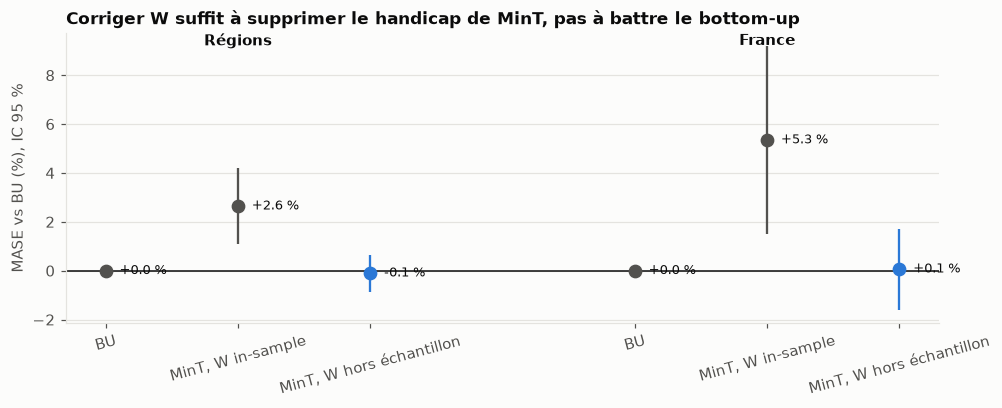

In [9]:
fig, ax = plt.subplots(figsize=(9, 3.6), layout="constrained")
labels_ = {"BU": "BU", "MinT shrink": "MinT, W in-sample", "MinT oos": "MinT, W hors échantillon"}
for i, level in enumerate(["Régions", "France"]):
    for j, m in enumerate(labels_):
        r = (metrics.relative_change(bl_oos, m, "BU", level) * 100) if m != "BU" else pd.Series([0.0])
        x = i * 4 + j
        color = viz.BLUE if m == "MinT oos" else viz.TEXT_2
        se = r.std() / np.sqrt(len(r)) if len(r) > 1 else 0
        ax.errorbar(x, r.mean(), yerr=1.96 * se, fmt="o", ms=8, color=color, capsize=0, elinewidth=1.5)
        ax.annotate(f"{r.mean():+.1f} %", (x, r.mean()), xytext=(9, 0), textcoords="offset points", va="center",
                    fontsize=8.5)
ax.axhline(0, color=viz.TEXT, lw=1)
ax.set_xticks([0, 1, 2, 4, 5, 6], list(labels_.values()) * 2, rotation=15)
ax.text(1, ax.get_ylim()[1], "Régions", ha="center", va="top", fontweight="semibold")
ax.text(5, ax.get_ylim()[1], "France", ha="center", va="top", fontweight="semibold")
ax.set_ylabel("MASE vs BU (%), IC 95 %"); ax.grid(axis="x", visible=False)
ax.set_title("Corriger W suffit à supprimer le handicap de MinT, pas à battre le bottom-up")
export(fig, "experience_w"); plt.show()

**Conclusion de l'expérience.**

- Avec W estimée sur les erreurs passées, **MinT n'est plus moins bon que le bottom-up** : l'écart tombe à
  environ zéro, et n'est plus significatif.
- Le handicap de MinT shrink venait donc bien de **W**, pas de la formule de MinT.
- Mais même bien informé, MinT **ne bat pas** le bottom-up ici. Une explication plausible : les erreurs
  régionales sont fortement corrélées et du même signe ; quand toutes les régions se trompent ensemble, il n'y a
  pas d'information « croisée » à exploiter, et la meilleure prévision du total est la somme des régions.

⚠️ **Point d'attention — ce que l'expérience ne dit pas.** « MinT oos » n'est pas une méthode prête pour la
production : il lui faut un historique d'erreurs de prévision (ici, 20 origines passées au minimum), et sa W
dépend de la fréquence des origines. C'est une **expérience de diagnostic**, qui isole une cause.

## 7. 🔬 H1, enfin testée correctement : les prévisions de base sont-elles biaisées ?

Le notebook 02 a montré que le test de biais sur résidus in-sample était sans valeur (résidus centrés par
construction). On le refait sur les **erreurs hors échantillon** : une erreur moyenne par origine et par série
(119 valeurs par série), test t HAC, correction de Holm sur 13 séries.

In [10]:
me = err.groupby(level="origin").mean()
me.columns = [prepare.short_name(c) for c in me.columns]
bias = inference.bias_table(me)
bias = bias.join(inference.holm(bias["p"], ALPHA)[["p_holm", "rejet"]])
display(bias[["mean", "se_hac", "t", "p_holm", "rejet"]]
        .rename(columns={"mean": "erreur moyenne (MW)", "se_hac": "e.-t. HAC", "t": "t HAC", "rejet": "biais (Holm 5 %)"})
        .style.format({"erreur moyenne (MW)": "{:+.1f}", "e.-t. HAC": "{:.1f}", "t HAC": "{:+.2f}", "p_holm": "{:.2f}"}))

,erreur moyenne (MW),e.-t. HAC,t HAC,p_holm,biais (Holm 5 %)
France,-4.6,100.1,-0.05,1.00,False
AURA,-4.1,18.9,-0.22,1.00,False
BFC,+1.0,4.7,+0.21,1.00,False
Bretagne,+7.5,10.2,+0.73,1.00,False
Centre-VdL,-2.7,4.7,-0.57,1.00,False
Grand Est,+3.7,10.3,+0.36,1.00,False
HdF,-4.1,10.2,-0.40,1.00,False
Normandie,+5.8,8.8,+0.66,1.00,False
N.-Aquitaine,-11.1,10.3,-1.09,1.00,False
Occitanie,-13.8,10.6,-1.31,1.00,False


**Conclusion du test.** H0 n'est rejetée pour **aucune** série : les erreurs moyennes sont petites devant leur
incertitude. Les prévisions de base MSTL ne sont pas biaisées sur l'année 2024.

💡 **Ce que cela élimine.** Le bloc 4 a montré que MinT propage le biais d'une série sur toutes les autres. Ce
n'est **pas** le mécanisme à l'œuvre ici : la perte de MinT shrink vient de W (§ 5 et 6), pas d'un biais de base.
Des trois hypothèses de la question d'entretien du bloc 4 (biais, W mal estimée, fenêtre inadaptée), c'est la
deuxième qui est confirmée.

## 8. Conclusion : le chiffre clé, et la réponse à l'objectif métier

In [11]:
k = metrics.key_figure(by_level, "MinT shrink", "BU")
display(pd.DataFrame(k).T.rename(columns={"mean": "variation moyenne", "std": "écart-type", "wins": "origines gagnées",
                                          "n_origins": "origines"})
        .style.format({"variation moyenne": "{:+.2%}", "écart-type": "{:.2%}", "min": "{:+.1%}", "max": "{:+.1%}",
                       "origines": "{:.0f}", "origines gagnées": "{:.0f}"}))
lam = diag.set_index("origin")["lambda"]
print(f"λ de Schäfer-Strimmer sur l'année : de {lam.min():.3f} à {lam.max():.3f} (médiane {lam.median():.3f})")

,variation moyenne,écart-type,min,max,origines,origines gagnées
Régions,+2.25%,7.70%,-16.6%,+31.4%,119,48
France,+5.31%,20.12%,-37.8%,+70.5%,119,53


λ de Schäfer-Strimmer sur l'année : de 0.005 à 0.028 (médiane 0.018)


### Le chiffre clé

> **Sur 119 origines de 2024, MinT shrink augmente le MASE régional de 2,3 % en moyenne par rapport au
> bottom-up** (+5,3 % au niveau France). Il fait moins bien sur les 13 séries, et ne gagne qu'à 40 % des
> origines. L'écart est significatif au test t après correction de Holm (p ≈ 0,05), à la limite pour les tests
> de Wilcoxon et HAC. Sur les 4 origines du protocole principal, il le baissait de 2 %, sans significativité. **La cause est identifiée** : W, estimée sur les résidus in-sample
> de MSTL, ne décrit pas les vraies erreurs de prévision. Estimée sur les erreurs passées, elle ramène MinT au
> niveau du bottom-up, sans le dépasser.

### La réponse à l'objectif métier

> *Livrer un jeu unique de prévisions dont la somme des régions reproduit exactement le total France.*

- **L'objectif est atteint par toutes les méthodes réconciliées** : l'incohérence est nulle (assertion
  < 1e-6 MW, vérifiée à chaque origine). L'arbitrage manuel du comité devient inutile.
- **La méthode à recommander ici est le bottom-up** : la plus simple, la plus transparente (chaque région
  garde sa prévision, le total est leur somme), et la plus précise sur cette hiérarchie. Elle est aussi la plus
  facile à défendre devant un comité : « le national est la somme des régions ».
- **MinT n'est pas à rejeter en général**, mais il ne doit pas être utilisé avec les résidus in-sample d'un
  modèle comme MSTL. Il faut estimer W sur des **erreurs de prévision** (backtest glissant), comme au § 6.

### Limites, et pistes

| Limite | Conséquence | Piste |
|---|---|---|
| Pas de météo ni de calendrier dans les modèles de base | les grosses erreurs (12 novembre) sont communes à toutes les régions | ajouter température et jours fériés aux modèles de base |
| Une seule hiérarchie, très plate (1 total, 12 feuilles) | MinT a peu de structure à exploiter | tester une hiérarchie plus profonde (régions × secteurs) |
| Une année d'évaluation, h = 24 h | conclusions valables pour ce régime | refaire sur 2023, et à d'autres horizons |
| Prévisions ponctuelles seulement | rien sur la calibration des intervalles | réconciliation probabiliste (blocs 4 et 6) |

📌 **À retenir — le mini-projet en cinq phrases.**
1. Les données ont été **vérifiées avant d'être utilisées** : défaut d'heure corrigé et compté, additivité testée.
2. La cohérence est **garantie et testée** : toute méthode réconciliée livre des chiffres qui somment exactement.
3. Sur 4 origines, MinT semblait gagner ; sur 119, il **perd** sur toutes les séries, avec une significativité
   limite : 4 origines ne suffisent pas à classer des méthodes.
4. La perte vient d'une hypothèse cachée de `mint_shrink` : **W estimée sur des résidus in-sample** qui ne
   ressemblent pas aux erreurs de prévision. Une expérience contrôlée le confirme.
5. Ici, le **bottom-up** est la bonne réponse : cohérent, simple, et le plus précis.